In [1]:
import pandas as pd 
import requests
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
from shapely.wkt import loads
from shapely.wkt import loads

#Load the crime data
crime = pd.read_csv('../data/crime_property.csv')

#look at first 5 rows
crime.head()

,Reported_Date,Occurrence_Category,Occurrence_Group,Occurrence_Type_Group,Intersection,Reported_Day,Reported_Month,Reported_Year,OBJECTID,Date Reported,x,y
0,3/26/2025 12:00:00 PM,Disorder,General Disorder,Trouble with Person,23 AV/110 ST,26,3,2025,1,2025/03/26,-1.263622e+07,7.067388e+06
1,3/26/2025 12:00:00 PM,Disorder,Provincial Statute Violations,Intoxicated Person,157 ST/STONY PLAIN RD,26,3,2025,2,2025/03/26,-1.264501e+07,7.083757e+06
2,3/26/2025 12:00:00 PM,Violent,Personal Violence,Assault,100 ST/106 AV,26,3,2025,3,2025/03/26,-1.263386e+07,7.085369e+06
3,3/26/2025 12:00:00 PM,Violent,Personal Violence,Assault,100A ST/101A AV,26,3,2025,4,2025/03/26,-1.263390e+07,7.083918e+06
4,3/27/2025 12:00:00 PM,Disorder,Provincial Statute Violations,Intoxicated Person,95 ST/106 AV,27,3,2025,5,2025/03/27,-1.263278e+07,7.085633e+06


In [2]:
#Load Edmonton neighbourhood boundaries
nb = pd.read_csv('../data/neighbourhood.csv')
print(nb.shape)
nb.head()

(407, 9)


,Neighbourhood Name,Neighbourhood Number,Descriptive Name,Description,Effective Start Date,Effective End Date,Civic Ward,Planning District,Geometry Multipolygon
0,ABBOTTSFIELD,2010,Abbottsfield,"Abbottsfield was once owned by E.F. Carey, one...",1981-10-01,NaN,Métis,North Central,MULTIPOLYGON (((-113.38763361949056 53.5761348...
1,ALBANY,3460,Albany,NaN,2011-06-13,NaN,Anirniq,Northwest,MULTIPOLYGON (((-113.56024507936962 53.6316036...
2,ALBERTA AVENUE,1010,Alberta Avenue,One of the city's older residential neighbourh...,1981-10-01,NaN,Métis,North Central,MULTIPOLYGON (((-113.49225733739199 53.5766166...
3,ALBERTA PARK INDUSTRIAL,4010,Alberta Park Industrial,This non-residential neighbourhood is largely ...,1981-10-01,NaN,Nakota Isga,Jasper Place,MULTIPOLYGON (((-113.59041036545489 53.5665379...
4,ALCES,6669,Alces,Formerly Decoteau North,2019-07-25,NaN,Sspomitapi,Ellerslie,MULTIPOLYGON (((-113.37648878753762 53.4248774...


In [3]:
print(crime.shape)
print(crime['Occurrence_Category'].value_counts())
print(crime['Reported_Year'].value_counts().sort_index())
print(crime['Intersection'].value_counts().head(20))


(79452, 12)
Occurrence_Category
Non-Violent    50254
Disorder       16831
Violent         7865
Traffic         2064
Weapons         1356
Drugs           1000
Other             82
Name: count, dtype: int64
Reported_Year
2025    65642
2026    13810
Name: count, dtype: int64
Intersection
137 AV/137 AV            1122
AIRPORT RD/KINGSWAY       727
115 AV/117 ST             701
123A ST/137 AV            686
48 AV/CALGARY TR          664
89 AV/178 ST              620
STONY PLAIN RD/           608
82 AV/83 ST               461
50 ST/50 ST               408
111 AV/KINGSWAY           403
170 ST/170 ST             399
23 AV/PARSONS RD          378
123A ST/138 AV            359
82 AV/89 ST               345
111 AV/GROAT RD           320
102 AV/102 ST             314
96 ST/103A AV             311
111 ST/111 ST             310
CALGARY TR/CALGARY TR     307
17 ST/17 ST               295
Name: count, dtype: int64


In [4]:
# Convert to proper date format
crime['Reported_Date'] = pd.to_datetime(crime['Reported_Date'])

print("Date range in our dataset:")
print("Earliest date:", crime['Reported_Date'].min())
print("Latest date:", crime['Reported_Date'].max())
print("Total days covered:", (crime['Reported_Date'].max() - crime['Reported_Date'].min()).days)

Date range in our dataset:
Earliest date: 2025-03-13 12:00:00
Latest date: 2026-03-11 12:00:00
Total days covered: 363


In [5]:
# Convert the boundary text into actual polygon shapes
nb['geometry'] = nb['Geometry Multipolygon'].apply(loads)

# Convert to a GeoDataFrame (like a regular DataFrame but geography-aware)
nb_geo = gpd.GeoDataFrame(nb, geometry='geometry', crs='EPSG:4326')

print("Shape:", nb_geo.shape)
print("Done!")

Shape: (407, 10)
Done!


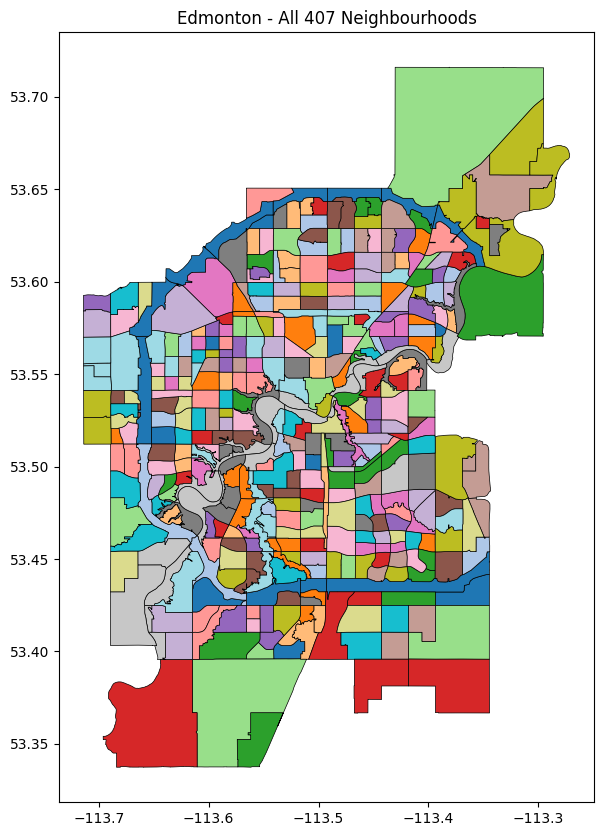

<Figure size 640x480 with 0 Axes>

In [ ]:
#Edmonton Map
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
nb_geo.plot(ax=ax, column='Neighbourhood Name', cmap='tab20', edgecolor='black', linewidth=0.5)
ax.set_title("Edmonton - All 407 Neighbourhoods")
plt.show()


In [7]:
#Convert crimes to points

# Convert crime x,y coordinates into Point objects
crime['geometry'] = crime.apply(lambda row: Point(row['x'], row['y']), axis=1)

# Convert to GeoDataFrame
crime_geo = gpd.GeoDataFrame(crime, geometry='geometry', crs='EPSG:3857')

# Convert to same coordinate system as neighbourhoods
crime_geo = crime_geo.to_crs('EPSG:4326')

print("Shape:", crime_geo.shape)
print("Done!")

Shape: (79452, 13)
Done!


In [8]:
# The spatial join - match each crime to a neighbourhood
crime_with_neighbourhood = gpd.sjoin(crime_geo, nb_geo[['Neighbourhood Name', 'Planning District', 'geometry']], 
                                      how='left', predicate='within')

print("Shape:", crime_with_neighbourhood.shape)
print("\nSample - first 5 crimes with their neighbourhood:")
crime_with_neighbourhood[['Occurrence_Category', 'Intersection', 'Neighbourhood Name']].head()

Shape: (79452, 16)

Sample - first 5 crimes with their neighbourhood:


,Occurrence_Category,Intersection,Neighbourhood Name
0,Disorder,23 AV/110 ST,KEHEEWIN
1,Disorder,157 ST/STONY PLAIN RD,BRITANNIA YOUNGSTOWN
2,Violent,100 ST/106 AV,MCCAULEY
3,Violent,100A ST/101A AV,DOWNTOWN
4,Disorder,95 ST/106 AV,MCCAULEY


In [9]:
# Count crimes per neighbourhood
crime_counts = crime_with_neighbourhood.groupby('Neighbourhood Name')['Occurrence_Category'].count().reset_index()
crime_counts.columns = ['Neighbourhood Name', 'Total Crimes']
crime_counts = crime_counts.sort_values('Total Crimes', ascending=False)

print("Top 20 most dangerous neighbourhoods right now:")
crime_counts.head(20)

Top 20 most dangerous neighbourhoods right now:


,Neighbourhood Name,Total Crimes
109,DOWNTOWN,4519
84,CLAREVIEW TOWN CENTRE,2025
395,WÎHKWÊNTÔWIN,1918
282,PRINCE RUPERT,1888
80,CENTRAL MCDOUGALL,1834
232,MCCAULEY,1773
53,BOYLE STREET,1262
31,BARANOW,1204
52,BONNIE DOON,1136
131,EMPIRE PARK,1121


In [10]:
# Count crimes per neighbourhood AND per category
crime_by_type = crime_with_neighbourhood.groupby(['Neighbourhood Name', 'Occurrence_Category']).size().reset_index()
crime_by_type.columns = ['Neighbourhood Name', 'Occurrence_Category', 'Count']

# Find most and least common crime type per neighbourhood
most_common = crime_by_type.loc[crime_by_type.groupby('Neighbourhood Name')['Count'].idxmax()]
most_common = most_common.rename(columns={'Occurrence_Category': 'Most Common Crime', 'Count': 'Most Common Count'})

least_common = crime_by_type.loc[crime_by_type.groupby('Neighbourhood Name')['Count'].idxmin()]
least_common = least_common.rename(columns={'Occurrence_Category': 'Least Common Crime', 'Count': 'Least Common Count'})

# Combine everything into one table
summary = crime_counts.merge(most_common[['Neighbourhood Name', 'Most Common Crime']], on='Neighbourhood Name')
summary = summary.merge(least_common[['Neighbourhood Name', 'Least Common Crime']], on='Neighbourhood Name')

summary.head(20)

,Neighbourhood Name,Total Crimes,Most Common Crime,Least Common Crime
0,DOWNTOWN,4519,Non-Violent,Other
1,CLAREVIEW TOWN CENTRE,2025,Non-Violent,Other
2,WÎHKWÊNTÔWIN,1918,Non-Violent,Other
3,PRINCE RUPERT,1888,Non-Violent,Drugs
4,CENTRAL MCDOUGALL,1834,Non-Violent,Traffic
5,MCCAULEY,1773,Non-Violent,Other
6,BOYLE STREET,1262,Non-Violent,Other
7,BARANOW,1204,Non-Violent,Weapons
8,BONNIE DOON,1136,Non-Violent,Drugs
9,EMPIRE PARK,1121,Non-Violent,Traffic


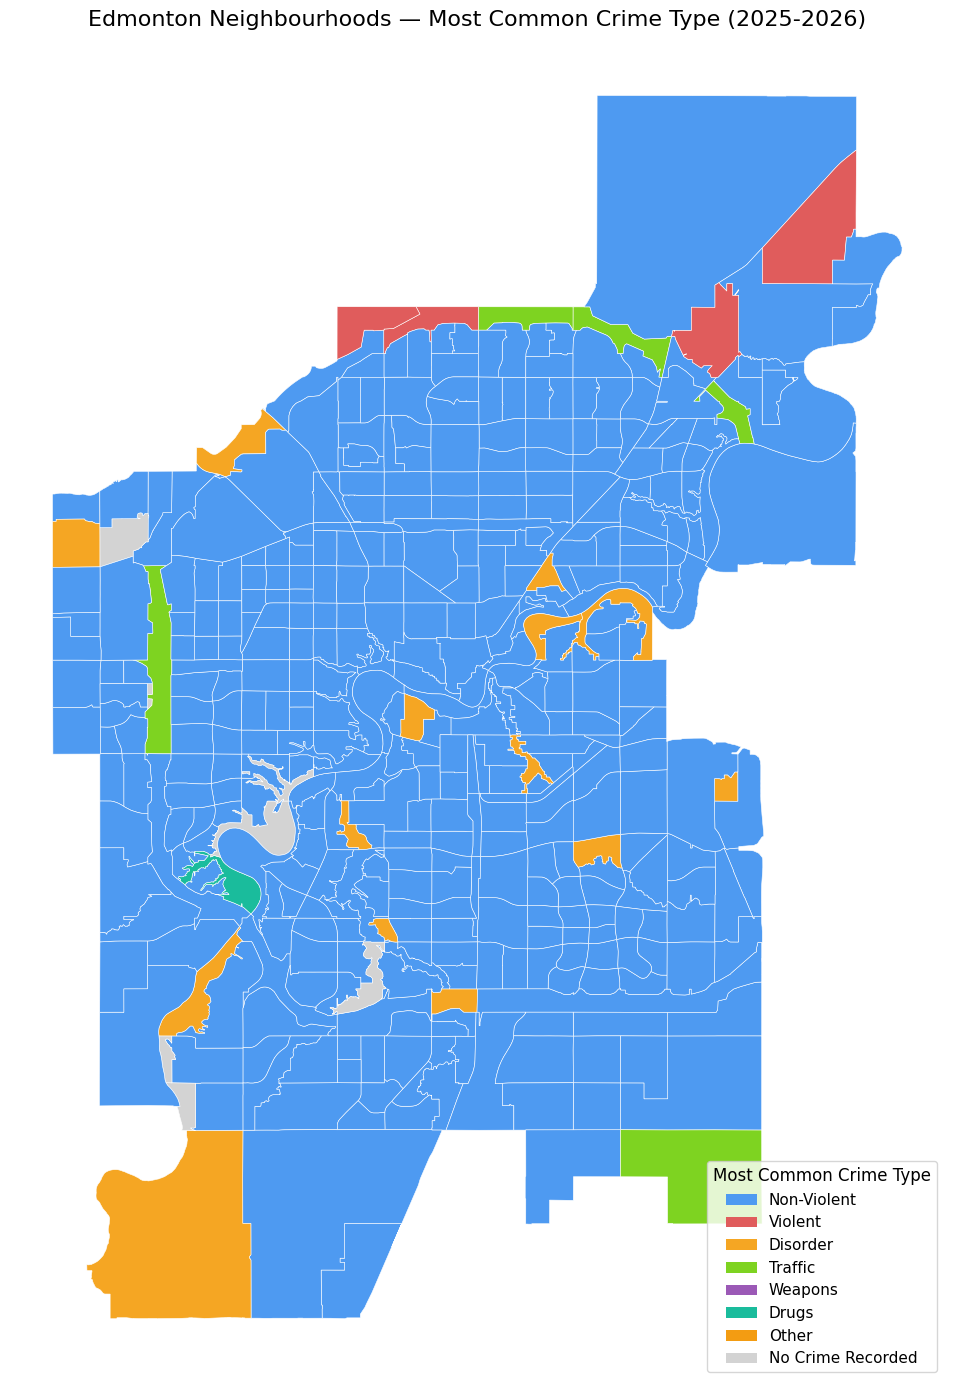

Saved!


In [34]:
#CRIME TYPE MAP
# Find most common crime type per neighbourhood
most_common_crime = crime_with_neighbourhood.groupby(['Neighbourhood Name', 'Occurrence_Category']).size().reset_index()
most_common_crime.columns = ['Neighbourhood Name', 'Occurrence_Category', 'Count']
most_common_crime = most_common_crime.loc[most_common_crime.groupby('Neighbourhood Name')['Count'].idxmax()]

# Merge with neighbourhood geodataframe
nb_crime_type = nb_geo.merge(most_common_crime[['Neighbourhood Name', 'Occurrence_Category']], 
                              on='Neighbourhood Name', how='left')

# Assign colors to each crime type, grey for no crime
color_map = {
    'Non-Violent': '#4E9AF1',    # blue
    'Violent':     '#E05C5C',    # red
    'Disorder':    '#F5A623',    # orange
    'Traffic':     '#7ED321',    # green
    'Weapons':     '#9B59B6',    # purple
    'Drugs':       '#1ABC9C',    # teal
    'Other':       '#F39C12',    # amber
}

nb_crime_type['color'] = nb_crime_type['Occurrence_Category'].map(color_map).fillna('#D3D3D3')

# Plot
fig, ax = plt.subplots(1, 1, figsize=(16, 14))
nb_crime_type.plot(ax=ax, color=nb_crime_type['color'], edgecolor='white', linewidth=0.4)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color, label=crime) for crime, color in color_map.items()]
legend_elements.append(Patch(facecolor='#D3D3D3', label='No Crime Recorded'))
ax.legend(handles=legend_elements, loc='lower right', fontsize=11, title='Most Common Crime Type', title_fontsize=12)

ax.set_title("Edmonton Neighbourhoods — Most Common Crime Type (2025-2026)", fontsize=16)
ax.axis('off')
plt.tight_layout()
plt.savefig('../results/crime_type_map.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

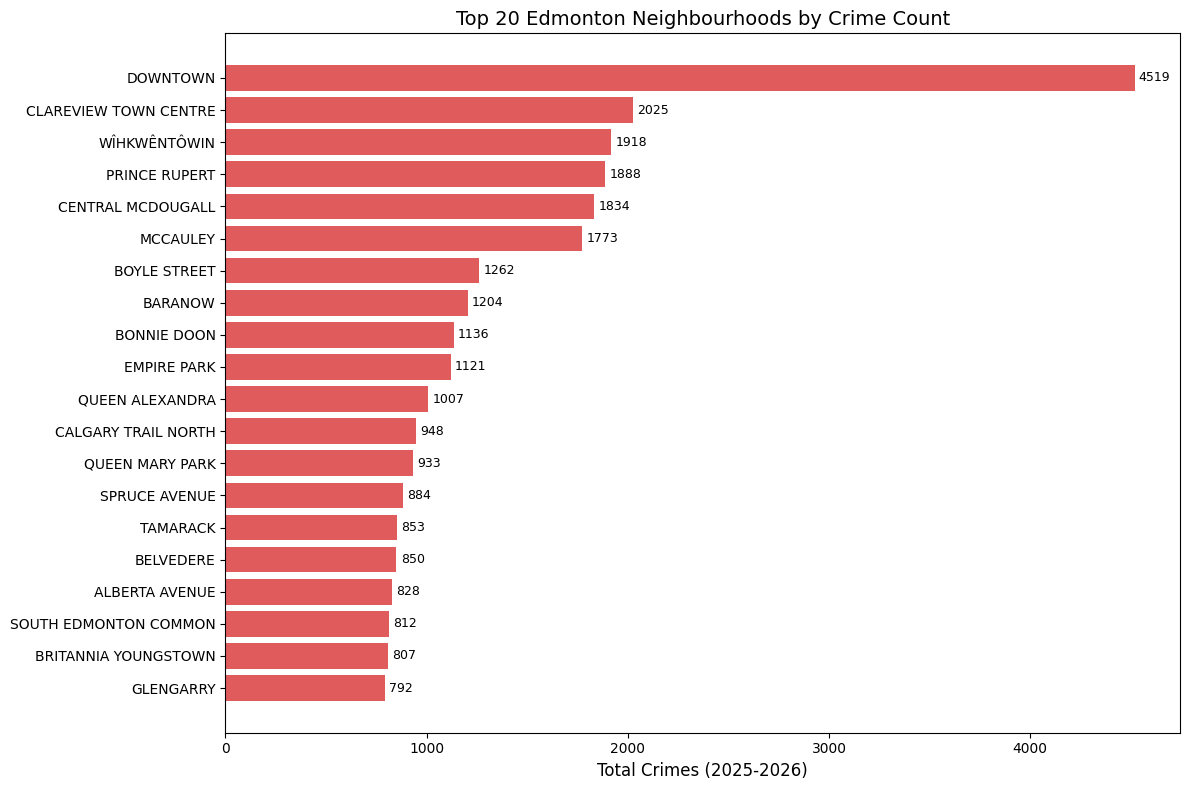

Saved!


In [12]:
#TOP 20 BAR CHART
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

top20 = crime_counts.head(20)
ax.barh(top20['Neighbourhood Name'][::-1], top20['Total Crimes'][::-1], color='#E05C5C')
ax.set_xlabel('Total Crimes (2025-2026)', fontsize=12)
ax.set_title('Top 20 Edmonton Neighbourhoods by Crime Count', fontsize=14)
ax.bar_label(ax.containers[0], padding=3, fontsize=9)
plt.tight_layout()
plt.savefig('../results/top20_crime_neighbourhoods.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

In [13]:
#LOAD CENSUS DATA

response = requests.get("https://data.edmonton.ca/resource/wpfd-8bii.json?$limit=1000")
census = pd.DataFrame(response.json())
print(census.shape)
print(census.columns.tolist())
census.head()
response = requests.get("https://data.edmonton.ca/resource/wpfd-8bii.json?$limit=50000")
census = pd.DataFrame(response.json())
print(census.shape)
print(census['gender'].unique())
print(census['neighbourhood'].nunique())

(1000, 8)
['neighbourhood', 'neighbourhood_number', 'question_type', 'gender', 'age_range', 'year', 'value', 'ward']
(20925, 8)
<StringArray>
['Men+', 'Total', 'Women+']
Length: 3, dtype: str
279


In [14]:
# Convert value to numeric
census['value'] = pd.to_numeric(census['value'], errors='coerce')

# Now find the best age range for total population
census[census['gender'] == 'Total'].groupby('age_range')['value'].sum().sort_values(ascending=False).head(10)

age_range
15 to 64 years       688340
0 to 14 years        184105
65 years and over    138465
30 to 34 years        87275
35 to 39 years        85780
25 to 29 years        77565
40 to 44 years        73860
20 to 24 years        67195
45 to 49 years        63740
5 to 9 years          62900
Name: value, dtype: int64

In [15]:
#CALCULATE POPULATION

# Non-overlapping age ranges that cover everyone
non_overlapping = [
    '0 to 4 years', '5 to 9 years', '10 to 14 years',
    '15 to 19 years', '20 to 24 years', '25 to 29 years',
    '30 to 34 years', '35 to 39 years', '40 to 44 years',
    '45 to 49 years', '50 to 54 years', '55 to 59 years',
    '60 to 64 years', '65 to 69 years', '70 to 74 years',
    '75 to 79 years', '80 to 84 years', '85 to 89 years',
    '90 to 94 years', '95 to 99 years', '100 years and over'
]

population = census[
    (census['gender'] == 'Total') & 
    (census['age_range'].isin(non_overlapping))
].groupby('neighbourhood')['value'].sum().reset_index()

population.columns = ['Neighbourhood Name', 'Population']
population['Neighbourhood Name'] = population['Neighbourhood Name'].str.upper()

print(population.shape)
print("Total Edmonton population:", population['Population'].sum())
population.head(10)

(279, 2)
Total Edmonton population: 1009430


,Neighbourhood Name,Population
0,ABBOTTSFIELD,1725
1,ALBANY,1695
2,ALBERTA AVENUE,6570
3,ALDERGROVE,5310
4,ALLARD,8265
5,ALLENDALE,2855
6,AMBLESIDE,6705
7,ARGYLL,825
8,ASPEN GARDENS,1650
9,ATHLONE,3260


In [16]:
#CRIME RATE
# Merge population with crime counts
crime_rate = crime_counts.merge(population, on='Neighbourhood Name', how='left')

# Calculate crime rate per 1000 people
crime_rate['Crime Rate per 1000'] = (crime_rate['Total Crimes'] / crime_rate['Population'] * 1000).round(1)

# Sort by crime rate
crime_rate = crime_rate.sort_values('Crime Rate per 1000', ascending=False)

print("Top 20 neighbourhoods by CRIME RATE (per 1000 people):")
crime_rate.head(20)

Top 20 neighbourhoods by CRIME RATE (per 1000 people):


,Neighbourhood Name,Total Crimes,Population,Crime Rate per 1000
24,UNIVERSITY OF ALBERTA,708,350.0,2022.9
3,PRINCE RUPERT,1888,1295.0,1457.9
112,GOODRIDGE CORNERS,177,245.0,722.4
21,MILL WOODS TOWN CENTRE,740,1185.0,624.5
1,CLAREVIEW TOWN CENTRE,2025,3800.0,532.9
7,BARANOW,1204,2385.0,504.8
5,MCCAULEY,1773,3675.0,482.4
13,SPRUCE AVENUE,884,1835.0,481.7
4,CENTRAL MCDOUGALL,1834,4480.0,409.4
41,HERITAGE VALLEY TOWN CENTRE,466,1225.0,380.4


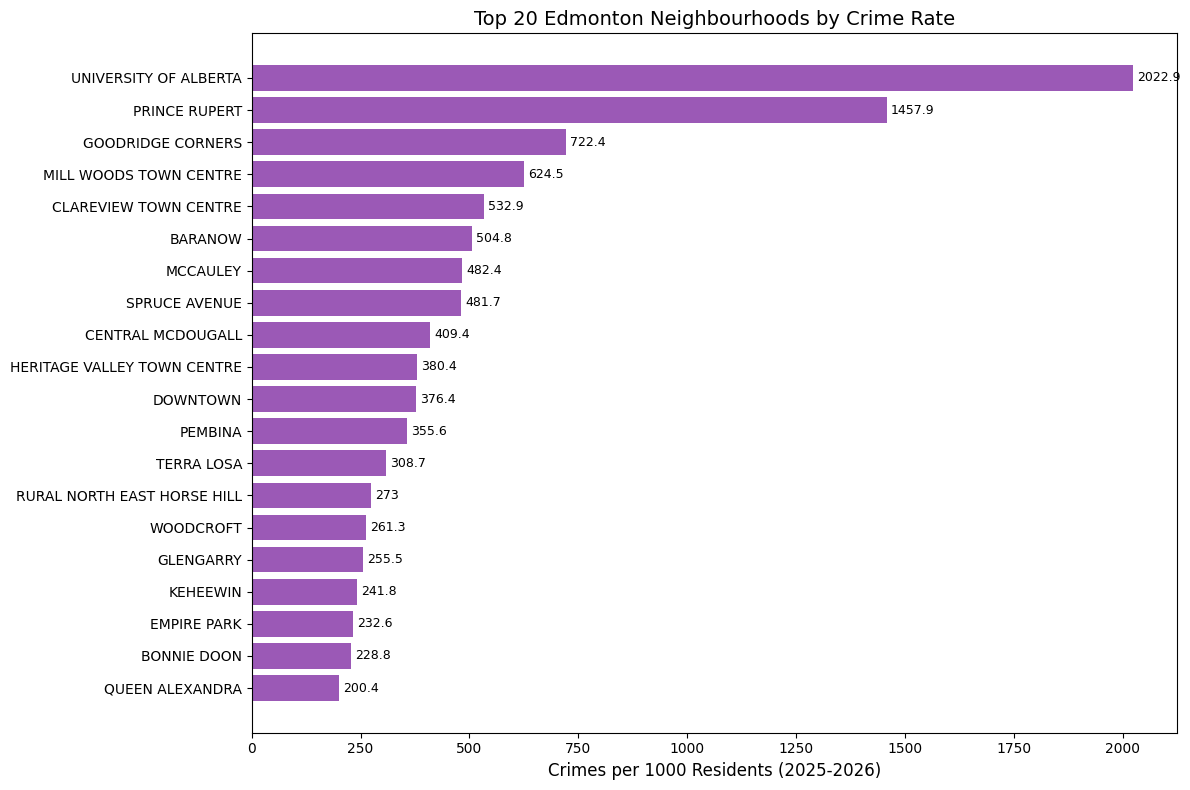

Saved!


In [17]:
#CRIME RATE BAR CHART
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

top20_rate = crime_rate.dropna(subset=['Crime Rate per 1000']).head(20)
ax.barh(top20_rate['Neighbourhood Name'][::-1], top20_rate['Crime Rate per 1000'][::-1], color='#9B59B6')
ax.set_xlabel('Crimes per 1000 Residents (2025-2026)', fontsize=12)
ax.set_title('Top 20 Edmonton Neighbourhoods by Crime Rate', fontsize=14)
ax.bar_label(ax.containers[0], padding=3, fontsize=9)
plt.tight_layout()
plt.savefig('../results/top20_crime_rate.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

In [18]:
# Step 17: Prepare features for clustering
# We need numeric features per neighbourhood
# We'll use: crime rate + breakdown of crime types as percentages

# First get crime type counts per neighbourhood
crime_features = crime_with_neighbourhood.groupby(
    ['Neighbourhood Name', 'Occurrence_Category']
).size().reset_index()
crime_features.columns = ['Neighbourhood Name', 'Occurrence_Category', 'Count']

print("Shape:", crime_features.shape)
crime_features.head(10)

Shape: (1963, 3)


,Neighbourhood Name,Occurrence_Category,Count
0,ABBOTTSFIELD,Disorder,28
1,ABBOTTSFIELD,Drugs,1
2,ABBOTTSFIELD,Non-Violent,84
3,ABBOTTSFIELD,Violent,16
4,ABBOTTSFIELD,Weapons,2
5,ALBANY,Disorder,25
6,ALBANY,Non-Violent,153
7,ALBANY,Traffic,2
8,ALBANY,Violent,11
9,ALBANY,Weapons,1


In [23]:
# Step 18 & 19: Pivot crime types and merge with crime rate
crime_pivot = crime_features.pivot_table(
    index='Neighbourhood Name',
    columns='Occurrence_Category',
    values='Count',
    fill_value=0
).reset_index()

cluster_data = crime_pivot.merge(
    crime_rate[['Neighbourhood Name', 'Crime Rate per 1000']], 
    on='Neighbourhood Name', 
    how='inner'
)

cluster_data = cluster_data.dropna(subset=['Crime Rate per 1000'])

print("Shape:", cluster_data.shape)
print("Columns:", cluster_data.columns.tolist())
cluster_data.head()

Shape: (276, 9)
Columns: ['Neighbourhood Name', 'Disorder', 'Drugs', 'Non-Violent', 'Other', 'Traffic', 'Violent', 'Weapons', 'Crime Rate per 1000']


,Neighbourhood Name,Disorder,Drugs,Non-Violent,Other,Traffic,Violent,Weapons,Crime Rate per 1000
0,ABBOTTSFIELD,28.0,1.0,84.0,0.0,0.0,16.0,2.0,75.9
1,ALBANY,25.0,0.0,153.0,0.0,2.0,11.0,1.0,113.3
2,ALBERTA AVENUE,209.0,22.0,404.0,0.0,31.0,134.0,28.0,126.0
5,ALDERGROVE,28.0,2.0,47.0,0.0,0.0,14.0,2.0,17.5
6,ALLARD,15.0,3.0,59.0,0.0,5.0,2.0,2.0,10.4


In [24]:
# Step 20: Scale the features so all variables have equal influence
from sklearn.preprocessing import StandardScaler

# Save neighbourhood names separately
neighbourhood_names = cluster_data['Neighbourhood Name']

# Get just the numeric features
features = cluster_data.drop('Neighbourhood Name', axis=1)

# Scale
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

print("Shape of scaled features:", features_scaled.shape)
print("Mean of each feature (should be ~0):", features_scaled.mean(axis=0).round(2))
print("Std of each feature (should be ~1):", features_scaled.std(axis=0).round(2))

Shape of scaled features: (276, 8)
Mean of each feature (should be ~0): [-0. -0.  0. -0.  0.  0.  0.  0.]
Std of each feature (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1.]


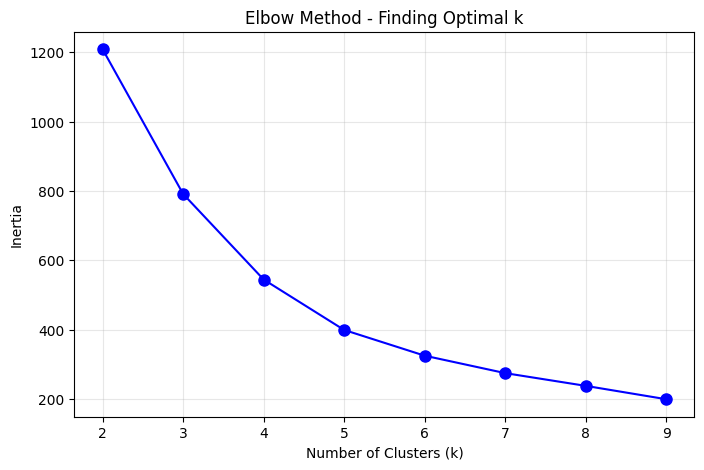

In [25]:
# Step 21: Use elbow method to find optimal number of clusters
from sklearn.cluster import KMeans

inertia = []
k_range = range(2, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(features_scaled)
    inertia.append(kmeans.inertia_)

# Plot the elbow
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, 'bo-', markersize=8)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method - Finding Optimal k')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.show()

In [27]:
# Step 22: Run k-means with k=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(features_scaled)

# Add cluster labels back to our data
cluster_data['Cluster'] = cluster_labels +1

# See how many neighbourhoods in each cluster
print("Neighbourhoods per cluster:")
print(cluster_data['Cluster'].value_counts().sort_index())

Neighbourhoods per cluster:
Cluster
1    248
2      3
3      1
4     24
Name: count, dtype: int64


In [28]:
# Step 23: Inspect each cluster
for i in range(1, 5):
    print(f"\n--- Cluster {i} ({len(cluster_data[cluster_data['Cluster']==i])} neighbourhoods) ---")
    print(cluster_data[cluster_data['Cluster']==i]['Neighbourhood Name'].tolist())


--- Cluster 1 (248 neighbourhoods) ---
['ABBOTTSFIELD', 'ALBANY', 'ALDERGROVE', 'ALLARD', 'ALLENDALE', 'AMBLESIDE', 'ARGYLL', 'ASPEN GARDENS', 'ATHLONE', 'AVONMORE', 'BALWIN', 'BANNERMAN', 'BATURYN', 'BEACON HEIGHTS', 'BEARSPAW', 'BEAUMARIS', 'BELGRAVIA', 'BELLE RIVE', 'BELLEVUE', 'BELMONT', 'BERGMAN', 'BEVERLY HEIGHTS', 'BISSET', 'BLACKBURNE', 'BLACKMUD CREEK', 'BLUE QUILL', 'BLUE QUILL ESTATES', 'BRANDER GARDENS', 'BRECKENRIDGE GREENS', 'BRINTNELL', 'BROOKSIDE', 'BULYEA HEIGHTS', 'CAERNARVON', 'CALDER', 'CALLAGHAN', 'CALLINGWOOD NORTH', 'CALLINGWOOD SOUTH', 'CAMERON HEIGHTS', 'CANON RIDGE', 'CANORA', 'CANOSSA', 'CAPILANO', 'CARLISLE', 'CARLTON', 'CARTER CREST', 'CASSELMAN', 'CAVANAGH', 'CHAMBERY', 'CHARLESWORTH', 'CLOVERDALE', 'CRAWFORD PLAINS', 'CRESTWOOD', 'CROMDALE', 'CRYSTALLINA NERA WEST', 'CUMBERLAND', 'CY BECKER', 'DALY GROVE', 'DECHENE', 'DECOTEAU', 'DELTON', 'DELWOOD', 'DESROCHERS AREA', 'DONSDALE', 'DOVERCOURT', 'DUGGAN', 'DUNLUCE', 'EAUX CLAIRES', 'EBBERS', 'EDGEMONT', 'E

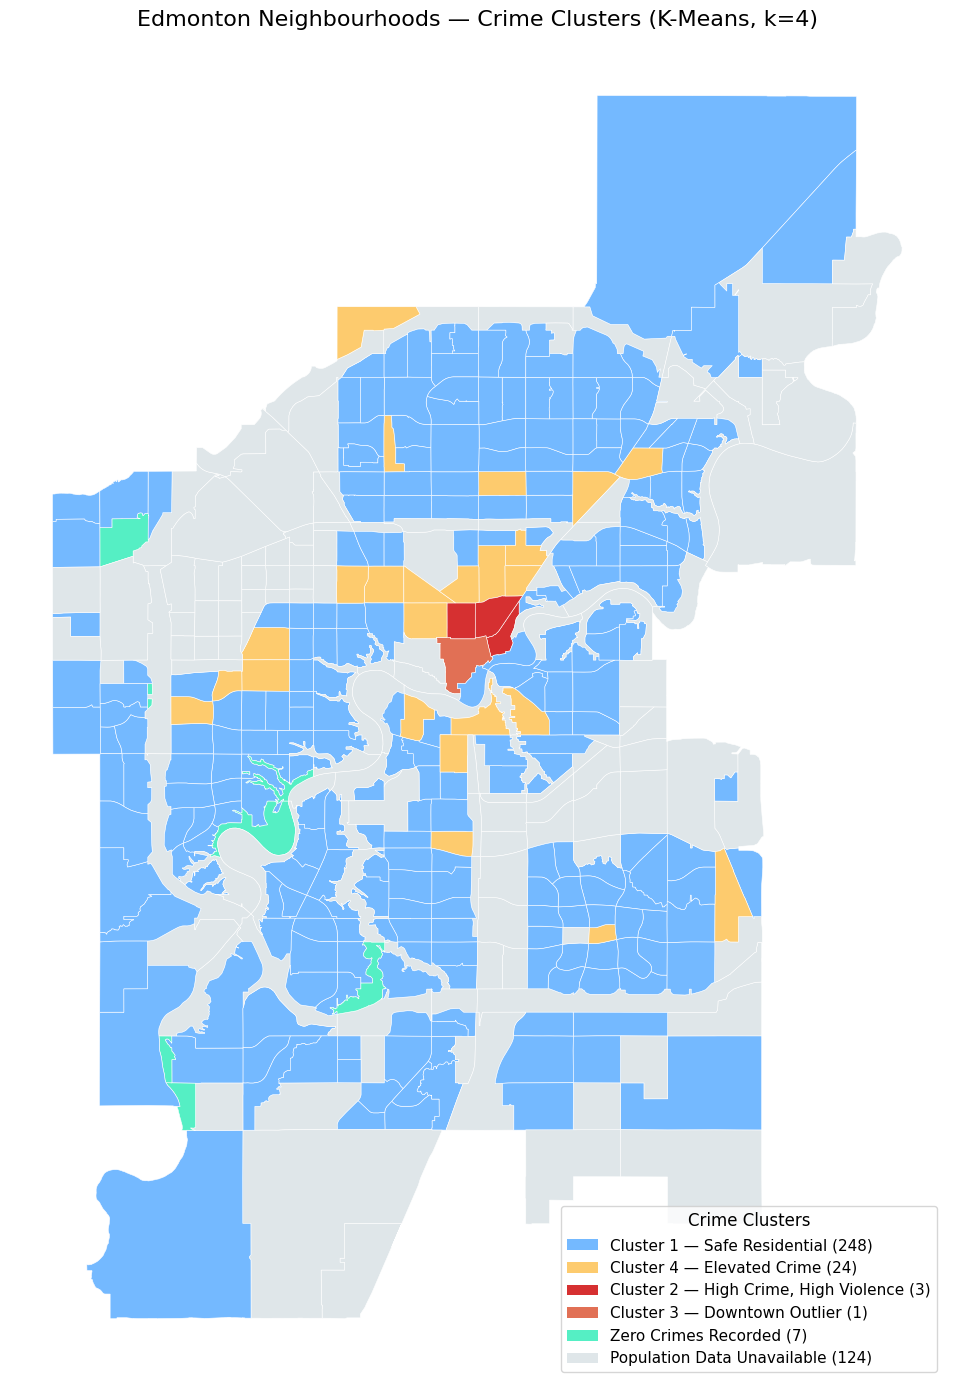

Saved!


In [30]:
# Step 24 updated: Visualize clusters with accurate labels
cluster_colors = {
    1: '#74B9FF',  # light blue - safe residential
    2: '#D63031',  # dark red - high crime high violence
    3: '#E17055',  # orange red - downtown outlier
    4: '#FDCB6E',  # amber - elevated crime
}

nb_clusters = nb_geo.merge(
    cluster_data[['Neighbourhood Name', 'Cluster']], 
    on='Neighbourhood Name', 
    how='left'
)

# Separate zero crime neighbourhoods from population unavailable
zero_crime = set(nb_geo['Neighbourhood Name']) - set(crime_counts['Neighbourhood Name'])

def assign_color(row):
    if row['Cluster'] in cluster_colors:
        return cluster_colors[row['Cluster']]
    elif row['Neighbourhood Name'] in zero_crime:
        return '#55EFC4'  # mint green - zero crime
    else:
        return '#DFE6E9'  # light grey - population unavailable

nb_clusters['color'] = nb_clusters.apply(assign_color, axis=1)

fig, ax = plt.subplots(1, 1, figsize=(16, 14))
nb_clusters.plot(ax=ax, color=nb_clusters['color'], edgecolor='white', linewidth=0.4)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#74B9FF', label='Cluster 1 — Safe Residential (248)'),
    Patch(facecolor='#FDCB6E', label='Cluster 4 — Elevated Crime (24)'),
    Patch(facecolor='#D63031', label='Cluster 2 — High Crime, High Violence (3)'),
    Patch(facecolor='#E17055', label='Cluster 3 — Downtown Outlier (1)'),
    Patch(facecolor='#55EFC4', label='Zero Crimes Recorded (7)'),
    Patch(facecolor='#DFE6E9', label='Population Data Unavailable (124)'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=11, title='Crime Clusters', title_fontsize=12)
ax.set_title("Edmonton Neighbourhoods — Crime Clusters (K-Means, k=4)", fontsize=16)
ax.axis('off')
plt.tight_layout()
plt.savefig('../results/crime_clusters_map.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

In [31]:
# Step 25: Cluster summary - average stats per cluster
cluster_summary = cluster_data.groupby('Cluster').agg(
    Neighbourhoods=('Neighbourhood Name', 'count'),
    Avg_Crime_Rate=('Crime Rate per 1000', 'mean'),
    Avg_Violent=('Violent', 'mean'),
    Avg_NonViolent=('Non-Violent', 'mean'),
    Avg_Disorder=('Disorder', 'mean')
).round(1)

print("Cluster Summary:")
cluster_summary

Cluster Summary:


,Neighbourhoods,Avg_Crime_Rate,Avg_Violent,Avg_NonViolent,Avg_Disorder
Cluster,,,,,
1,248,48.7,12.7,92.5,32.1
2,3,362.4,335.7,610.3,495.0
3,1,376.4,792.0,1821.0,1574.0
4,24,387.1,87.0,600.9,149.5
